# Demo 00: data tour

What the two data tiers contain and how the code reads them. The other demos build on this one.

* **`source_data/`** (Tier A, ~25 GB): the raw inputs -- trial-level recordings (HDF5), the 969 calibration images,
  the accentuated stimuli that were shown back to the animals, the exported encoding readouts, the robust
  ResNet-50 backbone, and the cluster analysis outputs (attacks, gradient spectra).
* **`preprocessed_data/`** (~0.5 GB): the per-monkey caches every figure reads, produced from `source_data/`
  by `scripts/preprocessing/build_all.py`. Read them through `pnc.preproc.loader`.

Both roots resolve through `pnc.paths` (`PNC_SOURCE_DATA`, `PNC_PREPROCESSED_DATA`); `paths.require` raises a
`MissingDataError` with the download command if something is absent.

In [1]:
%matplotlib inline
import os
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')   # multithreaded BLAS + torch can crash the Jupyter kernel on macOS
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import os, sys, time
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]   # kernel may start in the repo root or in notebooks/demos
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(REPO / 'notebooks' / 'demos'))
from pnc import paths
HINT = 'python data/download_data.py --tier source   (README section 2)'
# fail early, with the download command, if a data tier this demo reads is missing
paths.require(paths.source_data() / 'brain_data_encoding', HINT)
paths.require(paths.source_data() / 'stimuli_encoding', HINT)
paths.require(paths.source_data() / 'stimuli_control', HINT)
paths.require(paths.preprocessed_data() / 'brain_red.pkl', HINT)
paths.require(paths.preprocessed_data() / 'predictions_red.pkl', HINT)
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from pnc.utils import apply_figure_style
apply_figure_style(); plt.rcParams['figure.dpi'] = 90
torch.set_num_threads(max(1, os.cpu_count() // 2)); torch.manual_seed(0); np.random.seed(0)
print('source_data       =', paths.source_data())
print('preprocessed_data =', paths.preprocessed_data())

source_data       = /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/source_data
preprocessed_data = /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/preproc_build


## 1. What is on disk

`source_data/` is organised by kind of input. The listing below counts files per top-level directory (one
level down for the stimulus and prediction trees).

In [2]:
def tree(root, depth=1, max_children=12):
    root = Path(root)
    kids = sorted(p for p in root.iterdir() if not p.name.startswith('.'))
    for p in kids[:max_children]:
        if p.is_dir():
            n_files = sum(1 for _ in p.rglob('*') if _.is_file())
            print(f"{'  ' * (2 - depth)}{p.name + '/':60s} {n_files:6d} files")
            if depth > 0:
                tree(p, depth - 1, max_children=6)
        else:
            print(f"{'  ' * (2 - depth)}{p.name:60s} {p.stat().st_size / 1e6:8.1f} MB")
    if len(kids) > max_children:
        print(f"{'  ' * (2 - depth)}... {len(kids) - max_children} more")

print('source_data/'); tree(paths.source_data(), depth=1)
print('\npreprocessed_data/'); tree(paths.preprocessed_data(), depth=0, max_children=60)

source_data/
  accentuation_configs/                                           316 files
    hp_tuning_results/                                               66 files
    leap_250426-250501/                                              50 files
    paul_20250428-20250430/                                          50 files
    red_20250428-20250430/                                           50 files
    three0_250426-250501/                                            50 files
    venus_250426-250429/                                             50 files
  brain_data_control/                                               1 files
    vvs-accentuate_controlsessions_5monkeys_250504-250512.h5       6004.2 MB
  brain_data_controversial/                                         1 files
    vvs_accentuate_day3_normalize_red_20250123-20250126.hdf5        229.5 MB
  brain_data_encoding/                                             27 files
    leap_250426-250501_vvs-encodingstimuli_z1_rw80-250.h5    

  stimuli_control/                                               4619 files
    02-05-2025_red_20250428-20250430_AlexNet_training_seed_01_accentuation/     44 files
    02-05-2025_red_20250428-20250430_clipag_vitb32_accentuation/    231 files
    02-05-2025_red_20250428-20250430_dinov2_vitb14_reg_accentuation/     88 files
    02-05-2025_red_20250428-20250430_radio_v2.5-b_accentuation/      33 files
    02-05-2025_red_20250428-20250430_regnety_640_accentuation/       55 files
    02-05-2025_red_20250428-20250430_resnet50_accentuation/         187 files
    ... 44 more
  ... 2 more

preprocessed_data/
    BUILD_MANIFEST.json                                               0.0 MB
    MANIFEST.json                                                     0.0 MB
    axis_alignment.pkl                                                8.3 MB
    brain_controversial.pkl                                           6.7 MB
    brain_leap.pkl                                                    1.7 MB
    bra

## 2. Study constants (`pnc.utils`)

Five macaques, five target sites each (the most reliable channels of each array), ten DNN encoding models.
`MONKEY_UNITS` are the channel indices used everywhere (HDF5 columns, pickle names, figure tables).

In [3]:
from pnc.utils import (MONKEY_UNITS, MONKEY_DIRS, MODEL_ORDER, MODEL_SHORT_NAMES, ALL_MODELS,
                       ENCODING_HDF5_FILES, get_model_group, get_model_color)
from pnc.preproc import loader as L

sites = L.channels_df()                                  # region / reliability / firing floor per site
print(sites.to_string(index=False))
print()
print(pd.DataFrame({'model': MODEL_ORDER, 'short': [MODEL_SHORT_NAMES[m] for m in MODEL_ORDER],
                    'full name': [ALL_MODELS[m] for m in MODEL_ORDER],
                    'group': [get_model_group(m) for m in MODEL_ORDER]}).to_string(index=False))
print('\nsession directories:', MONKEY_DIRS)
print('encoding HDF5 files :', ENCODING_HDF5_FILES)

monkey  unit region  firing_floor  reliability
   red     0    aIT     -0.825888     0.249095
   red     2    aIT     -1.041645     0.510410
   red     9    aIT     -0.918934     0.268764
   red    15    aIT     -1.009476     0.335313
   red    19    aIT     -0.992926     0.237538
  paul     0    cIT     -2.037686     0.750501
  paul     8    cIT     -0.901622     0.067586
  paul    24    cIT     -0.907259     0.210846
  paul    40    cIT     -0.974086     0.049339
  paul    47    cIT     -1.413994     0.329293
 venus     9     V3    -14.888912     0.283786
 venus    79     V4    -14.269963     0.456320
 venus   151     V4    -11.067146     0.500959
 venus   331     V3    -10.120606     0.661628
 venus   355     V3    -11.005886     0.682710
  leap    81    STS    -25.377483     0.005710
  leap   282    STS    -19.612847     0.407647
  leap   286    STS    -19.113943     0.117415
  leap   306    STS    -17.517471    -0.057959
  leap   342    STS    -18.174021     0.317685
three0    56 

## 3. Raw calibration recordings (`source_data/brain_data_encoding/*.h5`)

One HDF5 per animal. `repavg/response_peak` is the trial-averaged standardized response of every channel to
each of the 969 calibration images; `trials/` keeps the single trials; `neuron_metadata/` holds the per-day
standardization constants (`mu`, `sigma`), reliability and noise-ceiling SNR. The train / test split used to
fit and select the encoding models is `stimuli_encoding/encoding_stimuli_split_seed0.csv`.

In [4]:
import h5py
from pnc.utils import load_encoding_hdf5, ENCODING_HDF5_DIR
h5_path = Path(ENCODING_HDF5_DIR) / ENCODING_HDF5_FILES['red']
with h5py.File(h5_path, 'r') as h:
    def show(name, obj):
        if isinstance(obj, h5py.Dataset) and not name.startswith('README'):
            print(f'  {name:45s} {str(obj.shape):16s} {obj.dtype}')
    h.visititems(show)

stim_names, resp, trial_stim, trial_resp = load_encoding_hdf5('red')
split = pd.read_csv(paths.source_data() / 'stimuli_encoding' / 'encoding_stimuli_split_seed0.csv')
assert (split.stimulus_name.values == stim_names).all()   # the split csv is row-aligned with the HDF5 stimulus order
print(f'\nMonkey R: {resp.shape[0]} images x {resp.shape[1]} channels; {trial_resp.shape[0]} trials')
print('split columns:', split.columns.tolist())
print(split[['is_nsd', 'is_floc', 'is_OO', 'is_train', 'is_test', 'is_normalizer']].sum().to_dict())

  neuron_metadata/brain_area/plexon             (64,)            object
  neuron_metadata/mu                            (3, 64)          float64
  neuron_metadata/ncsnr                         (64,)            float32
  neuron_metadata/reliability                   (64,)            float64
  neuron_metadata/sigma                         (3, 64)          float64
  neuron_metadata/temporal_windows              (60,)            int64
  repavg/response_peak                          (969, 64)        float64
  repavg/response_temporal                      (60, 969, 64)    float64
  repavg/stimulus_name                          (969,)           object
  stimulus_meta/duration_ms                     (8241,)          int64
  stimulus_meta/isi_ms                          (8241,)          int64
  stimulus_meta/ppd                             (16482,)         float64
  stimulus_meta/size_px                         (8241, 2)        uint16
  stimulus_meta/xy_deg                          (8241, 2)   

## 4. The accentuated (control) stimuli

`stimuli_control/<date>_<session>_<model>_accentuation/` holds the images synthesized for one model x monkey.
File names encode the target site, the seed image, the requested level and the level the synthesis
achieved: `<model>_RidgeCV_unit_<u>_img_<seed>_level_<target>_score_<achieved>.png`
(`pnc.utils.parse_stimulus_name`). Below: the ResNet-50 sweep for Monkey R, site 9, seed image 3.

11 levels; 02-05-2025_red_20250428-20250430_resnet50_accentuation


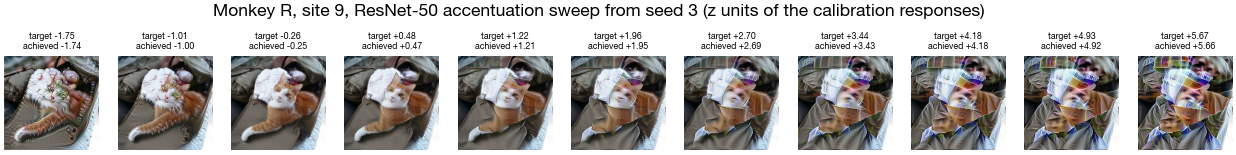

In [5]:
from pnc.utils import STIMULI_CONTROL_PATH, ACCENT_DATE_PREFIXES, parse_stimulus_name
from PIL import Image

def sweep_files(monkey, unit, model, seed):              # the images of one (site, seed) pair, ordered by requested level
    d = Path(STIMULI_CONTROL_PATH) / f"{ACCENT_DATE_PREFIXES[monkey]}_{MONKEY_DIRS[monkey]}_{model}_accentuation"
    rows = []
    for p in sorted(d.glob('*.png')):
        info = parse_stimulus_name(p.name)
        if info and info['unit'] == unit and info['seed'] == seed:
            rows.append(dict(path=p, **info))
    return sorted(rows, key=lambda r: r['target'])

sweep = sweep_files('red', 9, 'resnet50', seed=3)
print(f'{len(sweep)} levels;', sweep[0]['path'].parent.name)
fig, axes = plt.subplots(1, len(sweep), figsize=(1.6 * len(sweep), 2.1))
for ax, r in zip(axes, sweep):
    ax.imshow(Image.open(r['path']).convert('RGB')); ax.set_axis_off()
    ax.set_title(f"target {r['target']:+.2f}\nachieved {r['score']:+.2f}", fontsize=7)
fig.suptitle('Monkey R, site 9, ResNet-50 accentuation sweep from seed 3 (z units of the calibration responses)', y=1.02)
plt.show()

## 5. The preprocessed caches and the loader API (`pnc.preproc.loader`)

`L.load_brain(monkey)` is the processed brain data (calibration + control phases), `L.load_encoding(monkey)`
the encoding-model predictions of every model for the calibration images, `L.load_predictions(monkey)` the
cross-model predictions for every accentuated stimulus (`pred[stim, predicting_model, target_unit]`).
Higher-level accessors return ready-to-plot clouds: `L.control_cloud`, `L.encoding_cloud`, `L.anchor_cloud`,
and `L.control_table()` is the per-(monkey, unit, model) outcome table behind the main figures.

In [6]:
def describe(d, indent='  '):
    for k, v in d.items():
        if isinstance(v, dict):
            print(f'{indent}{k}/'); describe(v, indent + '  ')
        elif hasattr(v, 'shape'):
            print(f'{indent}{k:22s} {type(v).__name__} {tuple(v.shape)} {getattr(v, "dtype", "")}')
        elif isinstance(v, (list, tuple)):
            print(f'{indent}{k:22s} {type(v).__name__}[{len(v)}]')
        else:
            print(f'{indent}{k:22s} {type(v).__name__}: {str(v)[:70]}')

# the config / readout entries are long nested dicts; skipped so the listing stays readable
B = L.load_brain('red');       print('L.load_brain("red")');       describe({k: v for k, v in B.items() if k != 'config'})
E = L.load_encoding('red');    print('\nL.load_encoding("red")');  describe({k: v for k, v in E.items() if k != 'readout'})
P = L.load_predictions('red'); print('\nL.load_predictions("red")'); describe(P)

L.load_brain("red")
  monkey                 str: red
  units                  ndarray (5,) int64
  region                 ndarray (5,) object
  mu                     ndarray (5,) float64
  sigma                  ndarray (5,) float64
  firing_floor           ndarray (5,) float64
  firing_floor_avg       ndarray (5,) float64
  firing_floor_obs_min   ndarray (5,) float64
  reliability            ndarray (5,) float64
  control/
    trial_stim             ndarray (24690,) object
    trial_day              ndarray (24690,) object
    trial_z                ndarray (24690, 5) float32
    trial_kind             ndarray (24690,) object
    stim                   ndarray (5575,) object
    resp_z                 ndarray (5575, 5) float32
    n_reps                 ndarray (5575,) int64
    kind                   ndarray (5575,) object
  calibration/
    stim                   ndarray (969,) object
    resp_z                 ndarray (969, 5) float32
    trial_stim             ndarray (8241,) ob

In [7]:
tab = L.control_table()
print(tab.shape, 'rows = monkeys x units x models')
tab.query("monkey == 'red' and unit == 9").sort_values('control_r', ascending=False).round(3)

(250, 12) rows = monkeys x units x models


,monkey,unit,model,region,robust,n,encoding_r,control_r,control_slope,control_R2,enc_gen_R2,nc_r
28,red,9,resnet50_robust,aIT,1,110,0.877,0.569,0.189,-11.336,0.842,0.864
29,red,9,clipag_vitb32,aIT,1,110,0.879,0.481,0.108,-29.361,0.889,0.615
26,red,9,resnet50,aIT,0,110,0.867,0.282,0.053,-50.812,0.845,0.497
25,red,9,radio_v2.5-b,aIT,0,110,0.880,0.271,0.042,-77.232,0.866,0.000
27,red,9,resnet50_dino,aIT,0,110,0.866,0.266,0.047,-57.235,0.855,0.381
23,red,9,regnety_640,aIT,0,109,0.862,0.199,0.042,-39.468,0.839,0.622
21,red,9,siglip2_vitb16,aIT,0,110,0.866,0.056,0.011,-45.306,0.848,0.561
24,red,9,dinov2_vitb14_reg,aIT,0,110,0.860,-0.005,-0.001,-56.639,0.842,0.400
20,red,9,AlexNet_training_seed_01,aIT,0,109,0.661,-0.038,-0.006,-68.806,0.668,0.000
22,red,9,resnet50_clip,aIT,0,110,0.883,-0.064,-0.013,-48.362,0.868,0.506


## 6. One site: calibration responses and control clouds

Left: the calibration responses of Monkey R, site 9 (aIT) to the 969 images, with the encoding prediction of
ResNet-50 on the held-out split. Right: the **control cloud** of two models -- every accentuated image the
model synthesized for this site, predicted response (x) against the response the site actually gave (y).

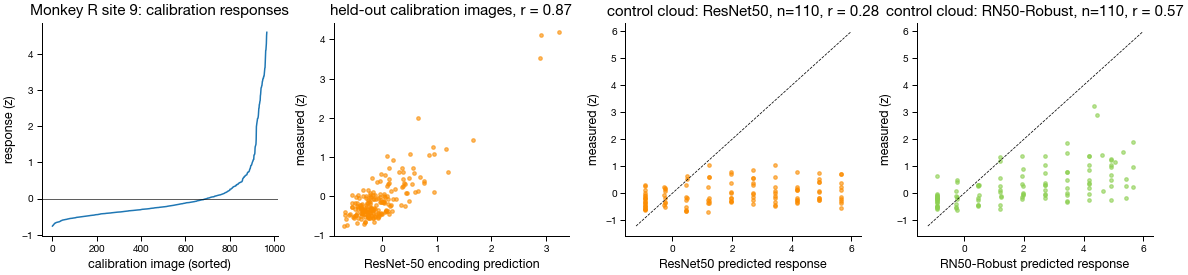

In [8]:
unit = 9; ui = list(B['units']).index(unit)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
ax = axes[0]
r = np.sort(B['calibration']['resp_z'][:, ui])           # sorted response profile: how selective the site is over the calibration set
ax.plot(r, lw=1.2); ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='calibration image (sorted)', ylabel='response (z)', title=f'Monkey R site {unit}: calibration responses')
ax = axes[1]
x, y = L.encoding_cloud('red', unit, 'resnet50', split='test')
ax.scatter(x, y, s=8, alpha=0.6, color=get_model_color('resnet50'))
ax.set(xlabel='ResNet-50 encoding prediction', ylabel='measured (z)', title=f'held-out calibration images, r = {np.corrcoef(x, y)[0, 1]:.2f}')
for ax, model in zip(axes[2:], ['resnet50', 'resnet50_robust']):
    x, y = L.control_cloud('red', unit, model)
    ax.scatter(x, y, s=8, alpha=0.6, color=get_model_color(model))
    lim = [min(x.min(), y.min()) - 0.3, max(x.max(), y.max()) + 0.3]
    ax.plot(lim, lim, 'k--', lw=0.6)                     # identity: perfect control would put every image on this line
    ax.set(xlabel=f'{MODEL_SHORT_NAMES[model]} predicted response', ylabel='measured (z)',
           title=f'control cloud: {MODEL_SHORT_NAMES[model]}, n={len(x)}, r = {np.corrcoef(x, y)[0, 1]:.2f}')
plt.tight_layout(); plt.show()

## Next

* `01_fit_encoding_model` -- fit the ridge readout from DNN features and select the layer.
* `02_feature_accentuation` -- synthesize an accentuation sweep along one encoding axis.
* `03_controversial_accentuation` -- images on which two models disagree.
* `04_adversarial_robustness` -- how fragile an encoding axis is under a bounded pixel attack.
* `05_gradient_spectra` -- the spatial-frequency content of the input gradient of an encoding axis.